## **Exploratory Data Analysis & Data Preparation**

#### **Objectives**
- Load and explore the resume dataset
- Perform comprehensive EDA
- Assess data quality
- Clean and prepare data for modeling

In [62]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [63]:
# Load dataset
df = pd.read_csv('dataset/resumeJD_pairs.csv', engine='python', on_bad_lines='skip')
print(f"Data Loaded Successfully: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

Data Loaded Successfully: 200 rows, 4 columns

Columns: ['resume_text', 'job_description', 'match_score', 'match_label']


In [64]:
# First look at the data
print("First 5 rows:")
df.head()

First 5 rows:


,resume_text,job_description,match_score,match_label
0,Data Scientist professional with over 7 years ...,We are hiring a highly skilled professional fo...,0.616,Medium Match
1,Data Scientist professional with over 6 years ...,We are hiring a highly skilled professional fo...,0.500,Medium Match
2,Data Scientist professional with over 6 years ...,We are hiring a highly skilled professional fo...,0.619,Medium Match
3,Machine Learning Engineer professional with ov...,We are hiring a highly skilled professional fo...,0.314,Low Match
4,Cloud Architect professional with over 7 years...,We are hiring a highly skilled professional fo...,0.903,High Match


In [65]:
# dataset information
print("Dataset Info:")
print("=" * 60)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      200 non-null    object 
 1   job_description  200 non-null    object 
 2   match_score      200 non-null    float64
 3   match_label      200 non-null    object 
dtypes: float64(1), object(3)
memory usage: 6.4+ KB


In [66]:
# statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,match_score
count,200.000000
mean,0.508820
std,0.221213
min,0.056000
25%,0.328250
50%,0.538500
75%,0.682000
max,0.958000


In [67]:
# text columns summary
print("\nText Columns Summary:")
df.describe(include='object')


Text Columns Summary:


,resume_text,job_description,match_label
count,200,200,200
unique,200,200,3
top,Data Scientist professional with over 7 years ...,We are hiring a highly skilled professional fo...,Medium Match
freq,1,1,89


In [68]:
# Check for the missing values
print("Missing Values Analysis:")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
print(missing_df)
print(f"\nTotal missing values: {missing.sum()}")

Missing Values Analysis:
                 Missing_Count  Percentage
resume_text                  0         0.0
job_description              0         0.0
match_score                  0         0.0
match_label                  0         0.0

Total missing values: 0


In [69]:
full_dupes = df.duplicated().sum()
print(f"Full duplicate rows: {full_dupes}")

Full duplicate rows: 0


In [70]:
pair_dupes = df.duplicated(subset=['resume_text', 'job_description']).sum()
print(f"Duplicate resume+JD pairs: {pair_dupes}")

Duplicate resume+JD pairs: 0


In [71]:
print("\nDuplicate rows:")
df[df.duplicated(subset=['resume_text', 'job_description'], keep=False)]


Duplicate rows:


,resume_text,job_description,match_score,match_label


In [72]:
# ─── Section: Uniqueness Checks ───────────────────────────────────────────────

print(f"Total rows:          {len(df)}")
print(f"Unique resumes:      {df['resume_text'].nunique()}")
print(f"Unique JDs:          {df['job_description'].nunique()}")
print(f"Unique resume+JD pairs: {df[['resume_text','job_description']].drop_duplicates().shape[0]}")


Total rows:          200
Unique resumes:      200
Unique JDs:          200
Unique resume+JD pairs: 200


In [73]:
# ─── Section: Label Consistency ───────────────────────────────────────────────

# What labels exist? (spot the case inconsistency!)
print("Unique labels found:")
print(df['match_label'].value_counts())

# Is the casing consistent?
print(f"\nExpected 3 labels, got: {df['match_label'].nunique()} unique values")
print("Distinct values:", df['match_label'].unique())


Unique labels found:
match_label
Medium Match    89
Low Match       71
High Match      40
Name: count, dtype: int64

Expected 3 labels, got: 3 unique values
Distinct values: ['Medium Match' 'Low Match' 'High Match']


In [74]:
print("Score distribution:")
print(df['match_score'].describe())
print()

# Scores must be between 0.0 and 1.0 — flag the bad ones
invalid_scores = df[(df['match_score'] < 0) | (df['match_score'] > 1)]
print(f"Invalid scores (out of 0–1 range): {len(invalid_scores)}")
print(invalid_scores[['match_label', 'match_score']])


Score distribution:
count    200.000000
mean       0.508820
std        0.221213
min        0.056000
25%        0.328250
50%        0.538500
75%        0.682000
max        0.958000
Name: match_score, dtype: float64

Invalid scores (out of 0–1 range): 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []


In [75]:
# ─── Section: Label vs Score Sanity Check ─────────────────────────────────────
# Do scores actually match what the label says?

print("Score stats per label (after lowercasing):")
df['match_label_lower'] = df['match_label'].str.lower()
print(df.groupby('match_label_lower')['match_score'].describe().round(2))

# Expected:
#   high   → 0.75 – 0.95
#   medium → 0.40 – 0.70
#   low    → 0.05 – 0.35


Score stats per label (after lowercasing):
                   count  mean   std   min   25%   50%   75%   max
match_label_lower                                                 
high match          40.0  0.81  0.07  0.70  0.76  0.79  0.88  0.96
low match           71.0  0.26  0.09  0.06  0.20  0.27  0.34  0.40
medium match        89.0  0.57  0.09  0.41  0.50  0.58  0.64  0.70


In [76]:
# ─── Section: Null Values ─────────────────────────────────────────────────────

print("Missing values per column:")
print(df.isnull().sum())
print()

# Show the rows with nulls
nulls = df[df.isnull().any(axis=1)]
print(f"Rows with at least one null: {len(nulls)}")
nulls[['match_label', 'match_score']].head(10)


Missing values per column:
resume_text          0
job_description      0
match_score          0
match_label          0
match_label_lower    0
dtype: int64

Rows with at least one null: 0


,match_label,match_score


In [77]:
# ─── Summary: All issues found ────────────────────────────────────────────────

print("=" * 50)
print("DATA QUALITY REPORT — merged_dataset.csv")
print("=" * 50)
print(f"  Total rows:             {len(df)}")
print(f"  Full duplicates:        {df.duplicated().sum()}")
print(f"  Duplicate pairs:        {df.duplicated(subset=['resume_text','job_description']).sum()}")
print(f"  Null resume_text:       {df['resume_text'].isnull().sum()}")
print(f"  Null job_description:   {df['job_description'].isnull().sum()}")
print(f"  Label case variants:    {df['match_label'].nunique()} (expected 3)")
print(f"  Invalid scores (<0/>1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")
print("=" * 50)

DATA QUALITY REPORT — merged_dataset.csv
  Total rows:             200
  Full duplicates:        0
  Duplicate pairs:        0
  Null resume_text:       0
  Null job_description:   0
  Label case variants:    3 (expected 3)
  Invalid scores (<0/>1): 0


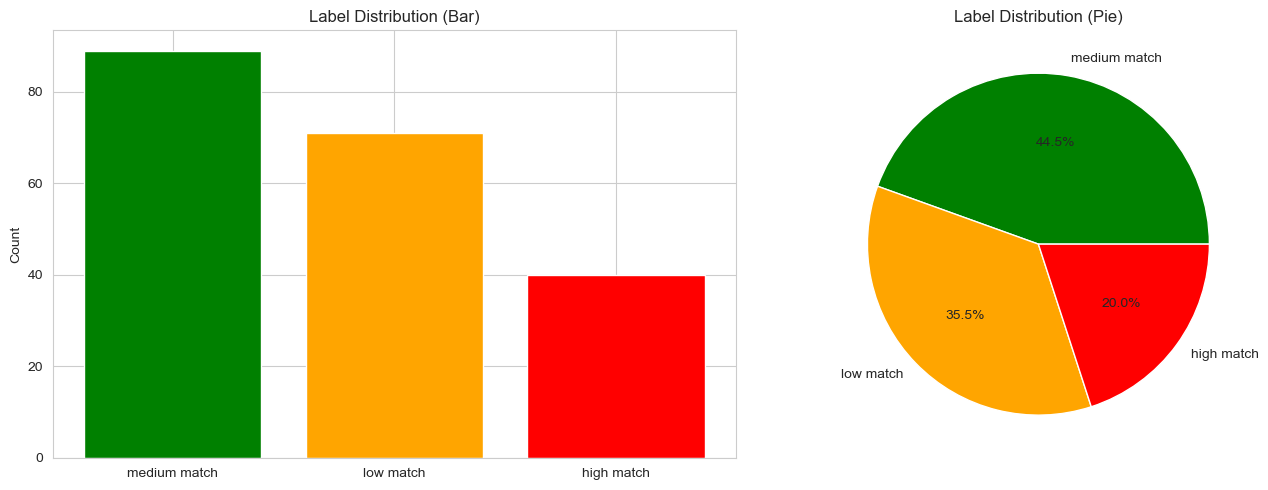

In [78]:
# Pie chart + bar side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['match_label'].str.lower().value_counts()

axes[0].bar(counts.index, counts.values, color=['green','orange','red'])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['green','orange','red'])
axes[1].set_title('Label Distribution (Pie)')

plt.tight_layout()
plt.show()


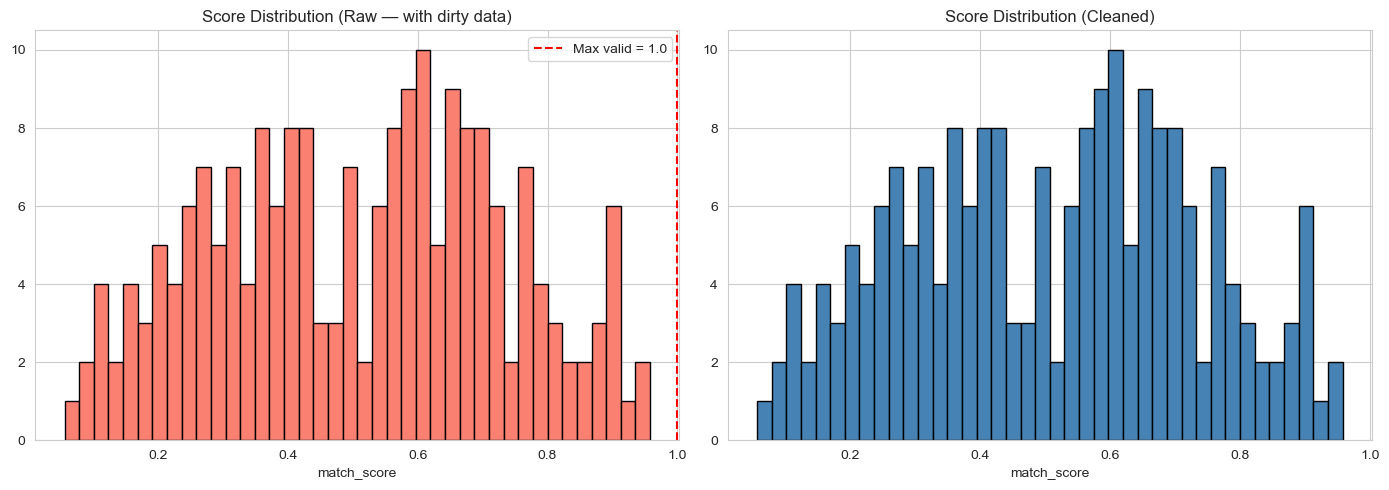

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
axes[0].hist(df['match_score'], bins=40, color='salmon', edgecolor='black')
axes[0].set_title('Score Distribution (Raw — with dirty data)')
axes[0].set_xlabel('match_score')
axes[0].axvline(1.0, color='red', linestyle='--', label='Max valid = 1.0')
axes[0].legend()

# After cleaning
clean = df[(df['match_score'] >= 0) & (df['match_score'] <= 1)]
axes[1].hist(clean['match_score'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Score Distribution (Cleaned)')
axes[1].set_xlabel('match_score')

plt.tight_layout()
plt.show()

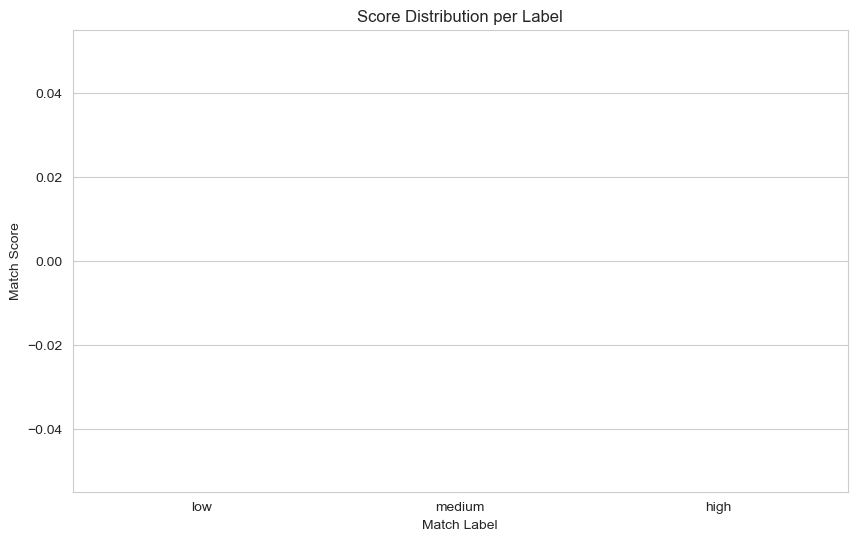

In [80]:
import seaborn as sns

df_plot = df.copy()
df_plot['match_label'] = df_plot['match_label'].str.lower()
df_plot = df_plot[(df_plot['match_score'] >= 0) & (df_plot['match_score'] <= 1)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x='match_label', y='match_score',
               order=['low','medium','high'],
               palette=['red','orange','green'])
plt.title('Score Distribution per Label')
plt.xlabel('Match Label')
plt.ylabel('Match Score')
plt.show()


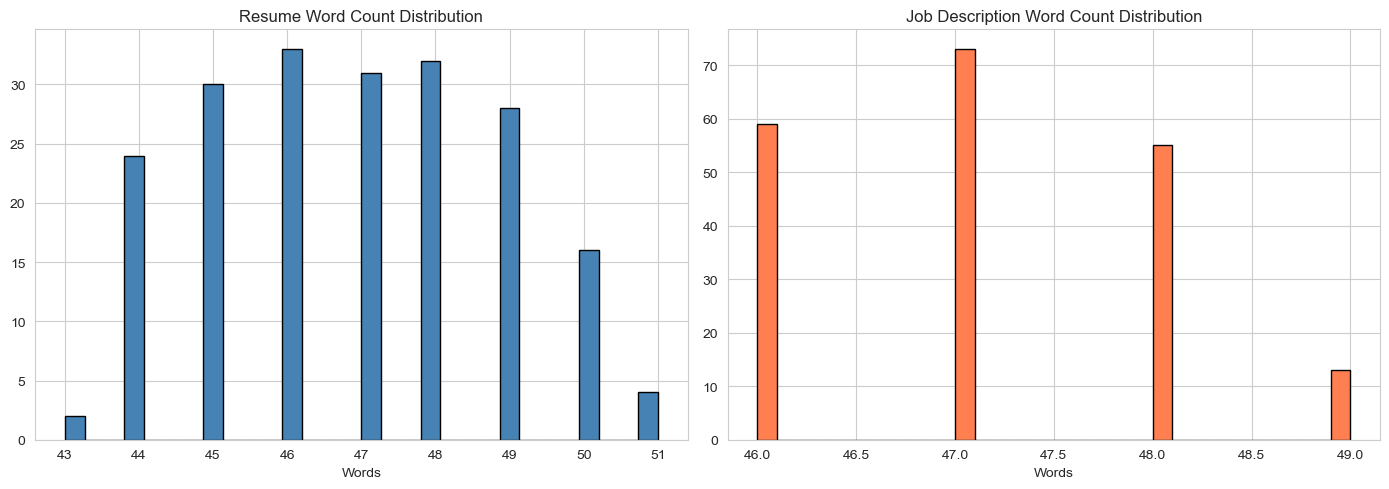

In [81]:
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len']     = df_plot['job_description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Job Description Word Count Distribution')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

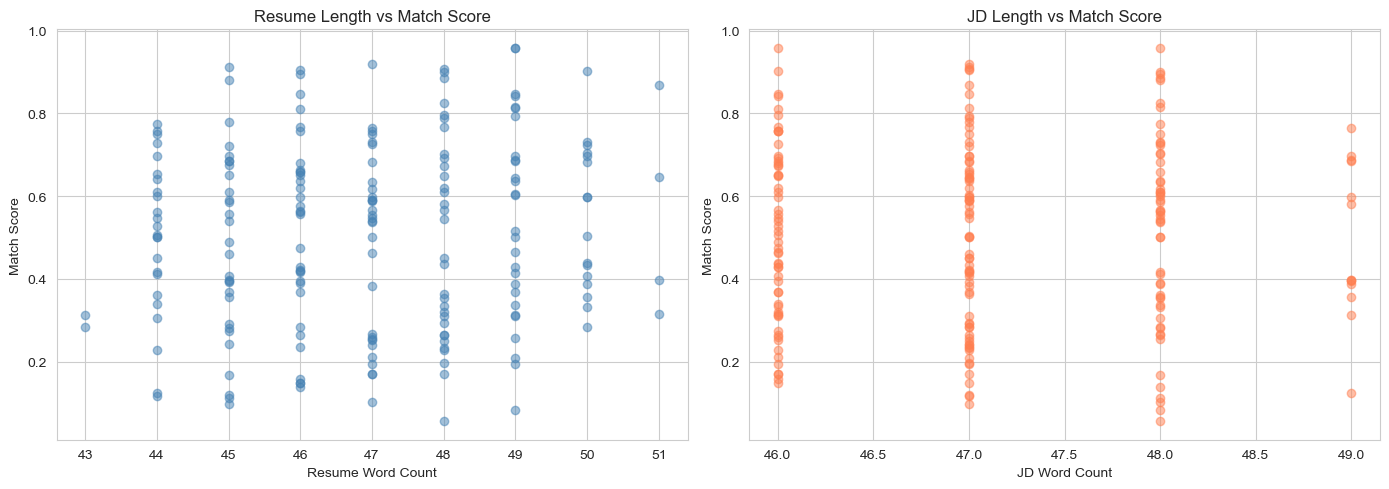

Resume length correlation: 0.094
JD length correlation:     0.006


In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

plt.tight_layout()
plt.show()

# Actual correlation values
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))
print("JD length correlation:    ", df_plot['jd_len'].corr(df_plot['match_score']).round(3))


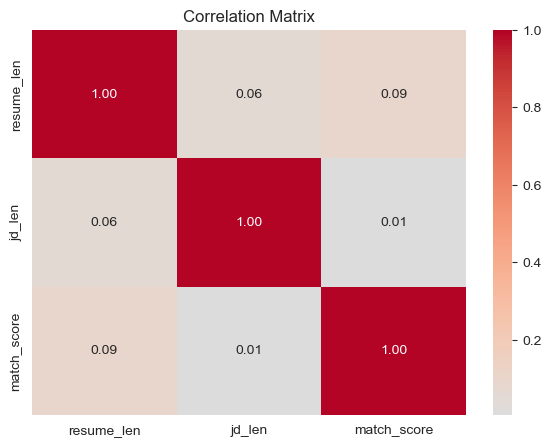

In [83]:
plt.figure(figsize=(7, 5))
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


In [84]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


ValueError: We need at least 1 word to plot a word cloud, got 0.

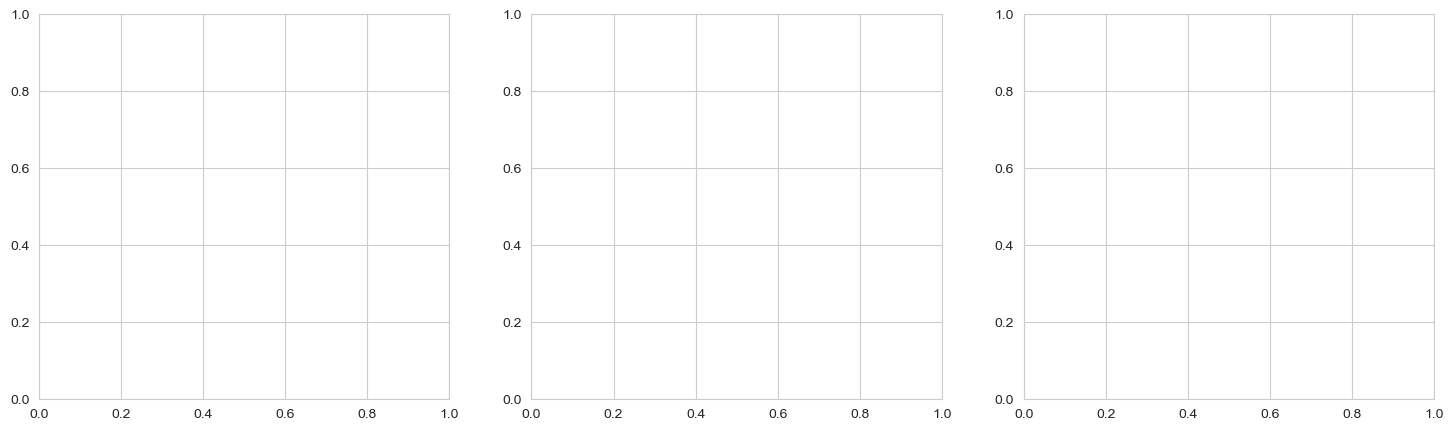

In [86]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels  = ['low', 'medium', 'high']
colors  = ['Reds', 'Oranges', 'Greens']

for ax, label, cmap in zip(axes, labels, colors):
    text = ' '.join(df_plot[df_plot['match_label'] == label]['resume_text'].dropna())
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} match resumes', fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Match Label', fontsize=16)
plt.tight_layout()
plt.show()


In [87]:
# Always record the starting point so that you  can see what changed
print("BEFORE CLEANING")
print("=" * 40)
print(f"Total rows:       {len(df)}")
print(f"Null resume_text: {df['resume_text'].isnull().sum()}")
print(f"Null job_desc:    {df['job_description'].isnull().sum()}")
print(f"Duplicates:       {df.duplicated().sum()}")
print(f"Label variants:   {df['match_label'].nunique()}")
print(f"Invalid scores:   {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")

df_clean = df.copy()

BEFORE CLEANING
Total rows:       200
Null resume_text: 0
Null job_desc:    0
Duplicates:       0
Label variants:   3
Invalid scores:   0


In [88]:
# Problem: 'high', 'High', 'HIGH' are treated as 3 different categories
print("Before:", df_clean['match_label'].value_counts().to_dict())

df_clean['match_label'] = df_clean['match_label'].str.lower().str.strip()

print("After: ", df_clean['match_label'].value_counts().to_dict())
print(f"\nUnique labels now: {df_clean['match_label'].nunique()} (expected 3)")

Before: {'Medium Match': 89, 'Low Match': 71, 'High Match': 40}
After:  {'medium match': 89, 'low match': 71, 'high match': 40}

Unique labels now: 3 (expected 3)


In [89]:
print(f"Before dropping nulls: {len(df_clean)} rows")

df_clean = df_clean.dropna(subset=['resume_text', 'job_description'])

print(f"After dropping nulls:  {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")

Before dropping nulls: 200 rows
After dropping nulls:  200 rows
Removed: 0 rows


In [90]:
print(f"Before removing duplicates: {len(df_clean)} rows")
print(f"Duplicate pairs found: {df_clean.duplicated(subset=['resume_text','job_description']).sum()}")

df_clean = df_clean.drop_duplicates(subset=['resume_text', 'job_description'], keep='first')

print(f"After removing duplicates:  {len(df_clean)} rows")

Before removing duplicates: 200 rows
Duplicate pairs found: 0
After removing duplicates:  200 rows


In [91]:
# Scores must be in [0.0, 1.0], anything else is a data error
invalid_mask = (df_clean['match_score'] < 0.0) | (df_clean['match_score'] > 1.0)
print(f"Invalid scores found: {invalid_mask.sum()}")
print(df_clean[invalid_mask][['match_label','match_score']])

df_clean = df_clean[~invalid_mask]
print(f"\nRows after removing invalid scores: {len(df_clean)}")

Invalid scores found: 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []

Rows after removing invalid scores: 200


In [92]:
#are the scores consistent with what the label claims?
# Expected: low=0.05-0.35, medium=0.40-0.70, high=0.75-0.95

print("Score range per label:")
print(df_clean.groupby('match_label')['match_score'].agg(['min','max','mean']).round(2))

# Flag any rows where label and score contradict each other
def label_score_mismatch(row):
    score = row['match_score']
    label = row['match_label']
    if label == 'high'   and score < 0.70: return True
    if label == 'medium' and (score < 0.35 or score > 0.75): return True
    if label == 'low'    and score > 0.40: return True
    return False

mismatches = df_clean.apply(label_score_mismatch, axis=1)
print(f"\nLabel-score mismatches: {mismatches.sum()}")
df_clean[mismatches][['match_label','match_score']]

Score range per label:
               min   max  mean
match_label                   
high match    0.70  0.96  0.81
low match     0.06  0.40  0.26
medium match  0.41  0.70  0.57

Label-score mismatches: 0


,match_label,match_score


In [93]:
# A 15-character resume or JD is useless for training
df_clean['resume_len'] = df_clean['resume_text'].str.split().str.len()
df_clean['jd_len']     = df_clean['job_description'].str.split().str.len()

print("Short texts found:")
print(f"  resume_text < 20 words: {(df_clean['resume_len'] < 20).sum()}")
print(f"  job_description < 10 words: {(df_clean['jd_len'] < 10).sum()}")

df_clean = df_clean[(df_clean['resume_len'] >= 20) & (df_clean['jd_len'] >= 10)]
print(f"\nRows after removing short texts: {len(df_clean)}")

Short texts found:
  resume_text < 20 words: 0
  job_description < 10 words: 0

Rows after removing short texts: 200


In [94]:
df_clean = df_clean.reset_index(drop=True)

print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)
print(f"  Original rows:        {len(df)}")
print(f"  Final rows:           {len(df_clean)}")
print(f"  Rows removed:         {len(df) - len(df_clean)}")
print()
print(f"  Nulls remaining:      {df_clean.isnull().sum().sum()}")
print(f"  Duplicates remaining: {df_clean.duplicated().sum()}")
print(f"  Label variants:       {df_clean['match_label'].nunique()}")
print(f"  Score range:          {df_clean['match_score'].min()} – {df_clean['match_score'].max()}")
print()
print("Label distribution after cleaning:")
print(df_clean['match_label'].value_counts())
print("=" * 45)

CLEANING SUMMARY
  Original rows:        200
  Final rows:           200
  Rows removed:         0

  Nulls remaining:      0
  Duplicates remaining: 0
  Label variants:       3
  Score range:          0.056 – 0.958

Label distribution after cleaning:
match_label
medium match    89
low match       71
high match      40
Name: count, dtype: int64


In [95]:
# Drop the helper columns we added during EDA
df_clean.to_csv('dataset/cleaned_resumeJD_pairs.csv', index=False)
print(f"Saved: dataset/cleaned_resumeJD_pairs.csv ({len(df_clean)} rows)")

Saved: dataset/cleaned_resumeJD_pairs.csv (200 rows)
